# **TELECOM X PARTE 2 - PREDICCIÓN DE CANCELACIÓN CHURN📉**

# **🛠️Preparación de los Datos**

### **Instalamos la librerías almacenadas en el archivo Requeriments.txt**

In [4]:
%pip install -r /content/Requeriments.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.0 MB/s eta 0:00:00


### **Asignación de alias a librerías**

In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

### **Cargando los datos**

Se utilizó [pandas](https://pandas.pydata.org/) para cargar y trabajar con el archivo dentro del entorno de trabajo, facilitando la organización, el análisis y la visualización de los datos. Además, se empleó el módulo [IPython.display](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.display) junto con su función principal [display](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.display), la cual permite mostrar los datos de forma clara y ordenada dentro del entorno. Gracias a esto, los objetos de Python, como los DataFrames, pueden visualizarse automáticamente en un formato de tabla fácil de interpretar, lo que ayuda a revisar rápidamente la estructura y el contenido de la información cargada.


In [6]:
try:
    # Importamos función
    from IPython.display import display

    #Cargamos los datos
    datos = '/content/Analisis_Telecom_X_Limpio_y_Transformado'
    df_telecomx = pd.read_csv(datos)

except Exception as e:
    # Archivo no cargado en el entorno de trabajo
    print(f'Error al extraer los datos: {e}')

else:
    # Usamos display() para ver el DataFrame formateado si no hay error
    pd.set_option('display.max_columns', None)
    display(df_telecomx.head())

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ChargesDaily_Total
0,0002-ORFBO,0,Female,0,1,1,9,DSL,0,1,0,1,1,0,1,0,One year,1,Mailed check,65.6,593.30,2.20
1,0003-MKNFE,0,Male,0,0,0,9,DSL,0,0,0,0,0,1,1,1,Month-to-month,0,Mailed check,59.9,542.40,2.01
2,0004-TLHLJ,1,Male,0,0,0,4,Fiber optic,0,0,1,0,0,0,1,0,Month-to-month,1,Electronic check,73.9,280.85,2.34
3,0011-IGKFF,1,Male,1,1,0,13,Fiber optic,0,1,1,0,1,1,1,0,Month-to-month,1,Electronic check,98.0,1237.85,3.17
4,0013-EXCHZ,1,Female,1,1,0,3,Fiber optic,0,0,0,1,1,0,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.97


### **Limpieza de Identificadores para la Optimización del Modelo Predictivo**

El flujo de procesamiento comienza con la creación de una copia de seguridad del DataFrame original y la eliminación de la columna `customerID`, ya que al ser un identificador único, carece de poder predictivo y podría inducir ruido o sobreajuste en el modelo de Machine Learning.

In [7]:
try:
    #Realizamos la copia del DataFrame original
    df_telecomx_nuevo = df_telecomx.copy()

    #Eliminamos la columna innecesaria
    df_telecomx_nuevo = df_telecomx_nuevo.drop(columns='customerID')
except Exception as e:
    print(f'Error al eliminar la columna customerID: {e}')
else:
    #Mostramos el resultado
    display(df_telecomx_nuevo.head())

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ChargesDaily_Total
0,0,Female,0,1,1,9,DSL,0,1,0,1,1,0,1,0,One year,1,Mailed check,65.6,593.30,2.20
1,0,Male,0,0,0,9,DSL,0,0,0,0,0,1,1,1,Month-to-month,0,Mailed check,59.9,542.40,2.01
2,1,Male,0,0,0,4,Fiber optic,0,0,1,0,0,0,1,0,Month-to-month,1,Electronic check,73.9,280.85,2.34
3,1,Male,1,1,0,13,Fiber optic,0,1,1,0,1,1,1,0,Month-to-month,1,Electronic check,98.0,1237.85,3.17
4,1,Female,1,1,0,3,Fiber optic,0,0,0,1,1,0,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.97


### **Consolidación de variables de telefonía**

Creación de columna Phone_Category basada en condiciones lógicas de PhoneService y MultipleLines. El objetivo es mitigar la multicolinealidad y unificar la información del servicio en una sola dimensión.

In [8]:
try:
    # Definimos las condiciones
    conditions = [
        (df_telecomx_nuevo['PhoneService'] == 1) & (df_telecomx_nuevo['MultipleLines'] == 1),
        (df_telecomx_nuevo['PhoneService'] == 0) & (df_telecomx_nuevo['MultipleLines'] == 0)
        ]

    # categorias
    categorias = ['Multiple Lines', 'No Phone Service']

    # Realizamos la operación y asignamos el valor a la columna
    df_telecomx_nuevo['Phone_Category'] = np.select(conditions, categorias, default='One Line')

except Exception as e:
    print(f'Error al crear la columna Phone_Category: {e}')
else:
    # visualizamos el resultado
    display(df_telecomx_nuevo.head())

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ChargesDaily_Total,Phone_Category
0,0,Female,0,1,1,9,DSL,0,1,0,1,1,0,1,0,One year,1,Mailed check,65.6,593.30,2.20,One Line
1,0,Male,0,0,0,9,DSL,0,0,0,0,0,1,1,1,Month-to-month,0,Mailed check,59.9,542.40,2.01,Multiple Lines
2,1,Male,0,0,0,4,Fiber optic,0,0,1,0,0,0,1,0,Month-to-month,1,Electronic check,73.9,280.85,2.34,One Line
3,1,Male,1,1,0,13,Fiber optic,0,1,1,0,1,1,1,0,Month-to-month,1,Electronic check,98.0,1237.85,3.17,One Line
4,1,Female,1,1,0,3,Fiber optic,0,0,0,1,1,0,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.97,One Line


### **Descripción del Proceso**

Utilizamos una estructura de control `try-except` para segmentar el DataFrame `df_telecomx_nuevo` en dos componentes esenciales:

* **Variable Objetivo ($y$):** Se extrae la columna **'Churn'**, que representa el evento que se desea predecir (en este caso, la fuga de clientes).
* **Variables Predictoras ($X$):** Se crea un nuevo conjunto que contiene todas las características del dataset original, excluyendo la columna 'Churn', mediante el método `.drop()`.

In [9]:
try:

  #Separamos el conjunto de Datos en 2 partes:

  # y: alamcenara la variable objetivo o interés
  y = df_telecomx_nuevo['Churn']

  # X: almacenara las variables explicativas
  X = df_telecomx_nuevo.drop(columns='Churn')

except Exception as e:
  print(f'Error al tratar la variable objetivo: {e}')
else:
  print('Cambios realizados exitosamente')

Cambios realizados exitosamente


### **Análisis de Proporción y Desequilibrio de la Variable Objetivo (Churn)**

Antes de proceder con el entrenamiento de modelos complejos, es fundamental entender la distribución de las etiquetas en nuestro dataset. Para ello, utilizamos el método `.value_counts()` sobre la variable objetivo `y`, almacenando las frecuencias absolutas en la variable `proporcion`.

**Interpretación de los Resultados:**
La visualización revela un desequilibrio de clases significativo entre los clientes que permanecen y los que abandonan la empresa:

* **Clase 0 (Clientes Activos):** Contamos con **5,376 registros**, lo que representa la gran mayoría de nuestra muestra.
* **Clase 1 (Churn/Abandono):** Contamos con **1,891 registros**, evidenciando que los casos de éxito (fuga de clientes) son considerablemente menores en comparación con la clase mayoritaria.

**Impacto en el Modelado:**
Este hallazgo es crítico, ya que trabajar con datos desequilibrados puede sesgar los algoritmos de Machine Learning, haciendo que estos prioricen la precisión en la clase mayoritaria mientras ignoran los casos de Churn. Esta observación justifica directamente la implementación posterior de técnicas de sobremuestreo como **SMOTE** y el uso de métricas más sensibles como el **Recall**, con el fin de garantizar que el modelo sea capaz de detectar eficazmente a los clientes en riesgo a pesar de ser la minoría en el dataset.

In [10]:
try:

  #Creamos variable que contiene la proporción por tipo
  proporcion = y.value_counts()
except Exception as e:
  print(f'Error revisar la variable objetivo: {e}')
else:
  #Mostramos el resultado
  display(proporcion)


,count
Churn,
0,5376
1,1891


### **Preprocesamiento y Transformación Automática de Datos**

Implementamos un objeto `ColumnTransformer` para aplicar transformaciones diferenciadas según la naturaleza de cada variable en el dataset:

* **Variables Categóricas:** Aplicamos la técnica [One-Hot Encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) (con el parámetro `drop='first'`) a columnas críticas como el tipo de servicio de internet, contrato y método de pago. Esto convierte los datos textuales en vectores numéricos binarios que el modelo puede interpretar, evitando al mismo tiempo el problema de la multicolinealidad.
* **Variables Numéricas:** Utilizamos [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) para estandarizar características como la antigüedad (`tenure`) y los cargos mensuales (`ChargesMonthly`). Este proceso asegura que todas las variables numéricas tengan una media de 0 y una desviación estándar de 1, evitando que las variables con escalas más grandes dominen injustamente el aprendizaje del modelo.

**Resultado del Procesamiento:**
Tras ajustar y transformar los datos (`X_procesado`), consolidamos el resultado en un nuevo DataFrame denominado `X_final`, recuperando los nombres de las columnas transformadas mediante el método `.get_feature_names_out()`. Como se observa en la visualización de las primeras filas (`.head()`), los datos ahora se presentan en una estructura matricial limpia y totalmente numérica, donde cada columna representa una característica específica lista para ser procesada por nuestros algoritmos de clasificación.

In [11]:
try:

  # Importamos las funciones
  from sklearn.compose import ColumnTransformer
  from sklearn.preprocessing import OneHotEncoder,StandardScaler

  # Creamos las variables con las columnas categóricas y numéricas
  categorical_features = ['InternetService', 'Contract', 'PaymentMethod', 'gender','Phone_Category']
  numeric_features = ['tenure', 'ChargesMonthly', 'ChargesTotal', 'ChargesDaily_Total']

  # Estructuramos la tranformacion y parametros para tratar las variables
  transformer = ColumnTransformer(transformers=[
  ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
  ('num', StandardScaler(), numeric_features)],
  remainder='passthrough' # Mantiene el resto de columnas si las hay
  )

  # Copiamos los datos de las variables explicativas para realizar la tranformacion en un objeto independiente
  X_transformer = X.copy()

  # Ajustar y transformar las variables explicativas
  X_procesado = transformer.fit_transform(X_transformer)

  # Creamos variable con los nombres de las columnas transformadas
  encoded_cols = transformer.get_feature_names_out(X_transformer.columns)

  # Creamos DataFrame con las datos transformados y estandarizados
  X_final = pd.DataFrame(X_procesado, columns=encoded_cols)

except Exception as e:
  print(f'Error al tratar las variables: {e}')
else:
  # Mostramos como quedo el resultado
  display(X_final.head())

,cat__InternetService_Fiber optic,cat__InternetService_No,cat__Contract_One year,cat__Contract_Two year,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,cat__gender_Male,cat__Phone_Category_No Phone Service,cat__Phone_Category_One Line,num__tenure,num__ChargesMonthly,num__ChargesTotal,num__ChargesDaily_Total,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__OnlineSecurity,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__StreamingTV,remainder__StreamingMovies,remainder__PhoneService,remainder__MultipleLines,remainder__PaperlessBilling
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.950200,0.029206,-0.744478,0.044360,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,-0.950200,-0.159990,-0.766925,-0.143739,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,-1.153700,0.304702,-0.882268,0.182959,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,-0.787401,1.104635,-0.460231,1.004654,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.194400,0.636624,-0.888200,0.806655,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0


# **🎯Correlación y Selección de Variables**

### **Análisis de Correlación de Variables Explicativas vs. Churn**

Para identificar qué factores tienen una relación estadística más fuerte con el abandono de clientes, realizamos un **análisis de correlación** entre todas las variables independientes del conjunto de datos procesado (`X_final`) y nuestra variable objetivo (`y`). Utilizamos el método `.corrwith()`, que calcula el coeficiente de correlación de Pearson para cada columna, y ordenamos los resultados de forma descendente para visualizar claramente las asociaciones positivas y negativas.

**Interpretación del Mapa de Calor (Heatmap):**
El gráfico permite identificar los principales impulsores del comportamiento de los clientes:

* **Correlaciones Positivas (Factores de Riesgo):** Las variables en verde oscuro indican que, a medida que su valor aumenta, también aumenta la probabilidad de abandono. Destacan el uso de **Internet de Fibra Óptica (0.3)** y el **Pago mediante Cheque Electrónico (0.29)** como los indicadores de riesgo más altos. Asimismo, los cargos mensuales elevados (`num__ChargesMonthly`) muestran una correlación positiva del **0.19** con el Churn.
* **Correlaciones Negativas (Factores de Retención):** Las variables en rojo intenso representan factores que protegen contra el abandono. La **antigüedad del cliente (`num_tenure`)** posee la correlación negativa más fuerte (**-0.34**), seguida de los **contratos a dos años (**-0.29**)**. Esto confirma que los clientes más antiguos y aquellos con compromisos contractuales a largo plazo son significativamente menos propensos a irse.
* **Neutralidad:** Variables como el género o el tipo de servicio telefónico muestran valores cercanos a cero, lo que sugiere que no tienen un impacto determinante por sí solos en la decisión de abandonar la empresa.

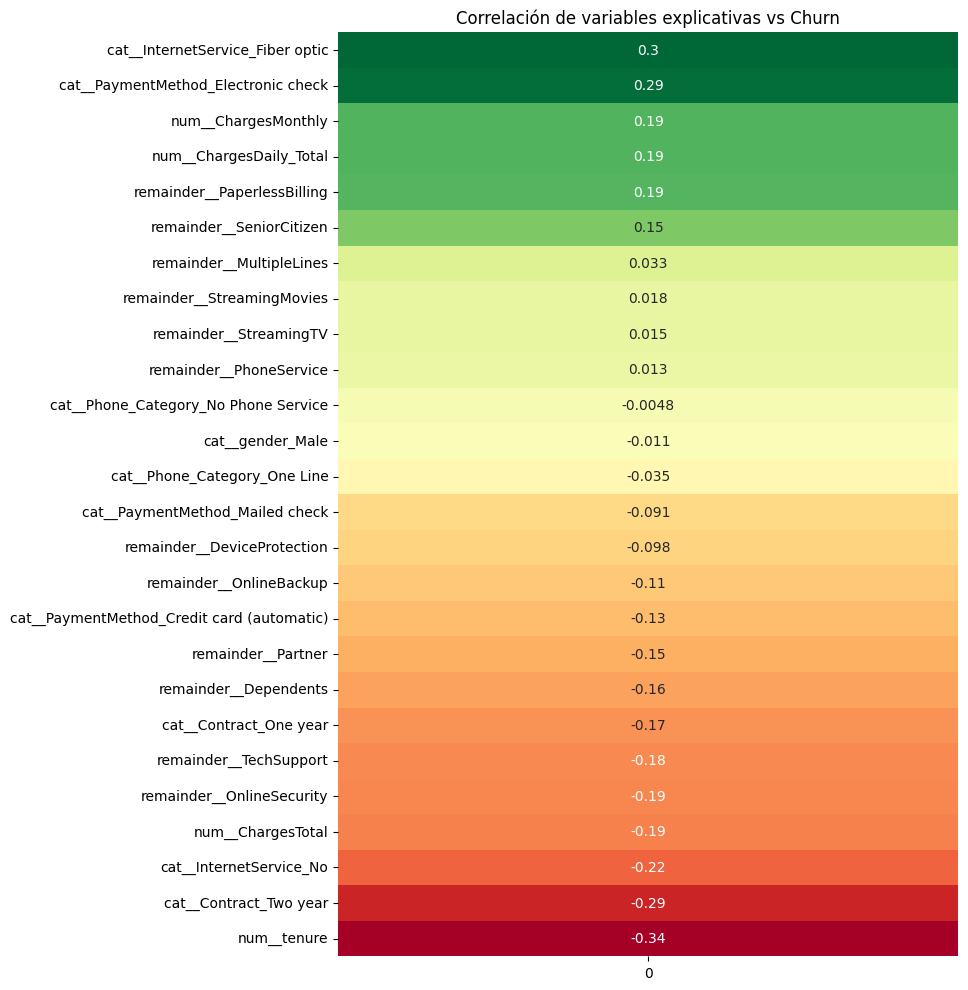

In [12]:
try:

  # Analizamos la correlacion de las variables explicativas con la variable objetivo
  corr_final = X_final.corrwith(y).sort_values(ascending=False)

  # Visualizamos el grafico con la correlacion
  plt.figure(figsize=(8, 12))
  sns.heatmap(corr_final.to_frame(), annot=True, cmap='RdYlGn', cbar=False)
  plt.title('Correlación de variables explicativas vs Churn')

except Exception as e:
  print(f'Error al realizar el análisis de correlación: {e}')
else:
  # mostramos el gráfico
  plt.show()

# **🤖Modelado Predictivo**

### **Realizamos la separación de los datos**
Tanto para entrenamiento, validación y prueba, para ser utilizados en los modelos predictivos.

In [13]:
try:

  # Importamos función
  from sklearn.model_selection import train_test_split

  # Primero: Separamos el 15% para el test final del total (X_final)
  # Segundo: El 85% restante se guarda en X_tratada
  X_tratada, X_test, y_tratada, y_test = train_test_split(
  X_final, y, test_size=0.15, stratify=y, random_state=42
  )

  # Tercero: Usamos X_tratada con el 85% de los datos para obtener los valores para el entrenamiento y validación
  # Separamos una proporcion de 15 tambien para la validacion del total (X_tratada)
  X_train, X_val, y_train, y_val = train_test_split(
  X_tratada, y_tratada, test_size=0.176, stratify=y_tratada, random_state=42
  )


except Exception as e:
  print(f'Error al realizar la división de los datos: {e}')
else:
  print('Datos divididos exitosamente')

Datos divididos exitosamente


### **Establecimiento del Modelo Base (Baseline)**

Implementamos un [DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) como modelo de referencia inicial. Este clasificador simple fue entrenado y evaluado con las particiones de datos previamente separadas para establecer un punto de comparación.

Obtenimos una **exactitud (Accuracy) del 73.9%** (aproximadamente 74%) tanto en el conjunto de entrenamiento como en el de prueba. Este valor refleja la proporción de la clase mayoritaria en nuestro dataset; es decir, el modelo acierta ese porcentaje simplemente prediciendo que ningún cliente abandonará el servicio. Sin embargo, el **26%** restante representa a los clientes que efectivamente cancelaron, a los cuales el modelo es incapaz de identificar.

Este resultado es técnicamente engañoso. Aunque una exactitud del 74% podría parecer aceptable a simple vista, el modelo carece de capacidad predictiva real para nuestro objetivo principal: detectar el **Churn**. La función crítica de este *baseline* no es clasificar, sino servir como el umbral mínimo de rendimiento que nuestros modelos avanzados deben superar obligatoriamente para ser considerados útiles.

In [14]:
try:

  #importamos la funcion
  from sklearn.dummy import DummyClassifier

  # Definimos el modelo BaseLine
  base_model = DummyClassifier(random_state=42)

  #Entrenamos el modelo
  base_model.fit(X_train, y_train)

except Exception as e:
  print(f'Error al entrenar el modelo BaseLine: {e}')
else:
  # Visualizamos el resultado del rendimiento del modelo para entrenamiento
  print(f' Rendimiento en entrenamiento: {base_model.score(X_train, y_train):.4f}')

  # Visualizamos el resultado del rendimiento del modelo para prueba
  print(f' Rendimiento en prueba: {base_model.score(X_val, y_val):.4f}')

 Rendimiento en entrenamiento: 0.7398
 Rendimiento en prueba: 0.7397


### **Identificación de la Profundidad Óptima para el Árbol de Decisión**

Desarrollamos este modelo con el objetivo de entrenarlo y evaluarlo utilizando las diferentes pofundidades. Buscamos determinar la capacidad de generalización del algoritmo para predecir con exactitud los motivos por los cuales los clientes cancelan los servicios contratados, permitiendo así el diseño de planes de acción proactivos que reduzcan la tasa de abandono (*Churn*).

Para evitar el sobreajuste (*overfitting*), ejecutamos múltiples validaciones iterando sobre distintos niveles de profundidad del árbol. El objetivo es encontrar el punto de equilibrio donde el modelo capture la complejidad necesaria de los datos sin memorizar el ruido del conjunto de entrenamiento.

Tras evaluar los resultados en los intervalos de prueba, identificamos que la **profundidad de 4** es la más equilibrada. Con esta configuración, el modelo alcanza un rendimiento de **0.7886** en entrenamiento y un sólido **0.8059** en validación. A diferencia de profundidades mayores (como 10 o 12), donde el rendimiento en entrenamiento sube drásticamente pero cae en prueba, la profundidad 4 garantiza que el modelo sea robusto y capaz de desempeñarse eficazmente ante datos nuevos.

In [15]:
try:

    # Importamos la función
    from sklearn.tree import DecisionTreeClassifier

    print('-- intervalos de 3 en 3 --')
    print('\n')

    # Lista con las diferentes profundidades en intervalos de 3 en 3
    profundidad = [3,6,9,12]

    # Bucle for donde aplicamos las diferentes validaciones
    for i in range(len(profundidad)):
      # Creamos el modelo y entrenamos
      modelo_arbol = DecisionTreeClassifier(max_depth=profundidad[i],random_state=42)
      modelo_arbol.fit(X_train, y_train)

      # Imprimimos los resultados obtenidos
      print(f'Profundidad: {profundidad[i]}⬇️')
      print(f'Rendimiento en entrenamiento: {modelo_arbol.score(X_train, y_train):.4f}')
      print(f'Rendimiento en prueba: {modelo_arbol.score(X_val, y_val):.4f}')
      print('\n')

    print('-- intervalos de 2 en 2 --')
    print('\n')

    # Lista con las diferentes profundidades en intervalos de 2 en 2
    profundidad_1 = [2,4,6,8,10]

    # Bucle for donde aplicamos las diferentes validaciones
    for i in range(len(profundidad_1)):
      # Creamos el modelo y entrenamos
      modelo_arbol = DecisionTreeClassifier(max_depth=profundidad_1[i],random_state=42)
      modelo_arbol.fit(X_train, y_train)

      # Imprimimos los resultados obtenidos
      print(f'Profundidad: {profundidad_1[i]}⬇️')
      print(f'Rendimiento en entrenamiento: {modelo_arbol.score(X_train, y_train):.4f}')
      print(f'Rendimiento en prueba: {modelo_arbol.score(X_val, y_val):.4f}')
      print('\n')

except Exception as e:
  print(f'Error al entrenar el modelo Árbol de Decisión: {e}')

-- intervalos de 3 en 3 --


Profundidad: 3⬇️
Rendimiento en entrenamiento: 0.7880
Rendimiento en prueba: 0.8059


Profundidad: 6⬇️
Rendimiento en entrenamiento: 0.8088
Rendimiento en prueba: 0.8096


Profundidad: 9⬇️
Rendimiento en entrenamiento: 0.8573
Rendimiento en prueba: 0.7801


Profundidad: 12⬇️
Rendimiento en entrenamiento: 0.9139
Rendimiento en prueba: 0.7351


-- intervalos de 2 en 2 --


Profundidad: 2⬇️
Rendimiento en entrenamiento: 0.7880
Rendimiento en prueba: 0.8059


Profundidad: 4⬇️
Rendimiento en entrenamiento: 0.7886
Rendimiento en prueba: 0.8059


Profundidad: 6⬇️
Rendimiento en entrenamiento: 0.8088
Rendimiento en prueba: 0.8096


Profundidad: 8⬇️
Rendimiento en entrenamiento: 0.8351
Rendimiento en prueba: 0.7912


Profundidad: 10⬇️
Rendimiento en entrenamiento: 0.8729
Rendimiento en prueba: 0.7682




### **Evaluación del Modelo: Árbol de Decisión Final**

Procedimos con la construcción del modelo definitivo de [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) utilizando la profundidad previamente optimizada de **4**. Tras entrenar el algoritmo con el conjunto de entrenamiento, evaluamos su desempeño con los datos de validación para analizar su capacidad de respuesta ante casos no vistos. Generamos una matriz de confusión y un reporte de clasificación detallado para auditar la precisión de las predicciones de abandono (*Churn*).

A pesar de alcanzar una exactitud (*Accuracy*) general del **81%**, los resultados revelan una debilidad crítica en la métrica más importante para este proyecto: el **Recall**. El modelo solo logró identificar correctamente a **120 clientes** que abandonaron, mientras que **163 clientes** (falsos negativos) pasaron desapercibidos por el sistema.

Con un **Recall de apenas 0.42** para la clase de abandono, el modelo está ignorando a más de la mitad de los clientes en riesgo. En un escenario de negocio, esto representa una pérdida de oportunidad significativa para intervenir y retener a dichos usuarios. Estos hallazgos confirman que el árbol de decisión simple es insuficiente para capturar la complejidad del problema, lo que justifica plenamente la transición hacia modelos de ensamble más avanzados.

-- Matriz de confusión ---




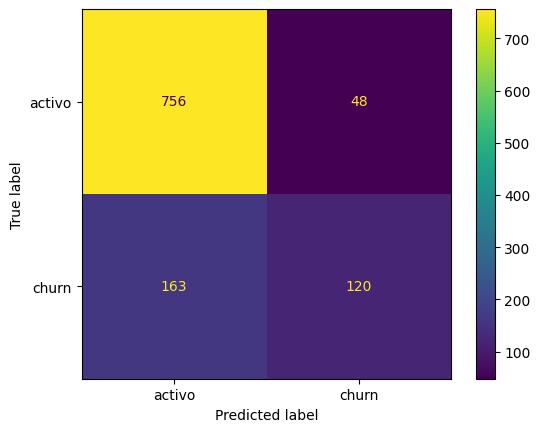



--- Reporte de Clasificación ---


              precision    recall  f1-score   support

           0       0.82      0.94      0.88       804
           1       0.71      0.42      0.53       283

    accuracy                           0.81      1087
   macro avg       0.77      0.68      0.70      1087
weighted avg       0.79      0.81      0.79      1087



In [16]:
try:

    # Importamos funciones
    from sklearn.metrics import confusion_matrix

    # Creamos modelo con la profundidad escogida
    modelo_arbol = DecisionTreeClassifier(max_depth=4,random_state=42)
    # Entrenamos el modelo con los datos de entrenamiento
    modelo_arbol.fit(X_train, y_train)
    # Variable con la prediccion del modelo para y_prevista
    y_prevista = modelo_arbol.predict(X_val)

    # Importamos la funcion para visualizar la matriz de confusión
    from sklearn.metrics import ConfusionMatrixDisplay

    print('-- Matriz de confusión ---')
    print('\n')

    # creamos visual de la matriz de confusión con y_val: validación y y_prevista: predicha por el modelo
    visual = ConfusionMatrixDisplay.from_predictions(y_val, y_prevista, display_labels=['activo','churn'])
    plt.show()
    print('\n')

    from sklearn.metrics import classification_report
    print("--- Reporte de Clasificación ---")
    print('\n')

    # Imprimimos el reporte del modelo con las diferentes métricas
    print(classification_report(y_val, y_prevista))

except Exception as e:
  print(f'Error al evaluar el modelo Árbol de Decisión: {e}')

### **Optimización con Pipeline, SMOTE y Validación Cruzada**

Implementamos un [Pipeline](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html) para establecer un flujo de trabajo robusto y secuencial. Este proceso integra [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) para abordar el desbalance de clases mediante la generación de muestras sintéticas, asegurando que el modelo aprenda equitativamente de ambas categorías. Para garantizar la fiabilidad de los resultados, utilizamos [StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html) con `n_splits=5`, lo que divide el conjunto de datos en cinco grupos (4 de entrenamiento y 1 de prueba por cada iteración), manteniendo siempre la proporción original de las clases en cada pliegue.

Finalmente, aplicamos [cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html) para promediar el rendimiento del modelo a través de las diferentes particiones. Este método nos permite conocer la estabilidad del algoritmo y asegurar que su desempeño no se deba a una distribución aleatoria favorable de los datos.

#### **Métricas de Evaluación Seleccionadas**

Durante la validación cruzada, monitoreamos las siguientes métricas fundamentales:

*
**Recall (Sensibilidad):** Mide la capacidad del modelo para localizar todos los casos positivos reales (clientes que abandonan) dentro del conjunto de datos.


*
**Precision (Precisión):** Evalúa la calidad de las predicciones positivas, indicando qué porcentaje de las alertas de abandono son aciertos reales.


*
**F1-Score:** Funciona como la media armónica entre precisión y recall, siendo la métrica ideal para buscar un equilibrio técnico entre ambas.



**Conclusión del Análisis:** Dado que nuestro objetivo principal es minimizar la pérdida de clientes, hemos seleccionado el **Recall** como la métrica crítica de éxito. En nuestras pruebas, obtuvimos un **Recall promedio de 0.7679** (aproximadamente 77%) con una desviación estándar de apenas **0.0198**, lo que confirma que el modelo es altamente estable y capaz de identificar correctamente a la gran mayoría de los clientes en riesgo de abandono.

In [17]:
try:

    # Importamos funciones
    from sklearn.model_selection import StratifiedKFold
    from imblearn.pipeline import Pipeline as imbpipeline
    from imblearn.over_sampling import SMOTE
    from sklearn.model_selection import cross_validate

    # Definimos el modelo
    modelo_arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
    # Creamos pipeline
    pipeline = imbpipeline([('over_sampler', SMOTE(random_state=42)), ('modelo', modelo_arbol)])
    # Definimos los parametros para StratifiedKFold
    sfk = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # Realizamos la validacion cruzada con los datos sin los valores de prueba
    resultados = cross_validate(pipeline, X_tratada, y_tratada, cv=sfk, scoring=['recall','f1', 'precision'],return_train_score=True)

    print('--Resultados de metricas--')
    print('\n')

    for i,v in enumerate(resultados):
      print(f'Parametros: {v}')
      print(f'Promedio: {resultados[v].mean():.4f}')
      print('\n')

    print('--Seleccionamos el Recall: Calculamos el Promedio y desvío estándar del Recall--✅')
    print(f"Recall promedio: {resultados['test_recall'].mean():.4f}")
    print(f"Estabilidad (Desviación Estándar): {resultados['test_recall'].std():.4f}")

except Exception as e:
  print(f'Error al realizar la validación cruzada: {e}')

--Resultados de metricas--


Parametros: fit_time
Promedio: 0.0775


Parametros: score_time
Promedio: 0.0130


Parametros: test_recall
Promedio: 0.7679


Parametros: train_recall
Promedio: 0.7735


Parametros: test_f1
Promedio: 0.6036


Parametros: train_f1
Promedio: 0.6069


Parametros: test_precision
Promedio: 0.4983


Parametros: train_precision
Promedio: 0.4998


--Seleccionamos el Recall: Calculamos el Promedio y desvío estándar del Recall--✅
Recall promedio: 0.7679
Estabilidad (Desviación Estándar): 0.0198


### **Cálculo del Intervalo de Confianza**

Para determinar la fiabilidad y el rango esperado de rendimiento de nuestro modelo en producción, calculamos el **intervalo de confianza** basado en los resultados del Recall obtenidos durante la validación cruzada. Este cálculo utiliza el promedio y la desviación estándar para definir un margen de certidumbre estadística.

Implementamos un intervalo de confianza de dos desviaciones estándar ($2\sigma$), lo que nos proporciona un **nivel de confianza aproximado del 95%**. Según los datos procesados, el Recall esperado para nuevos conjuntos de datos oscila entre **0.7283** y **0.8074**. Este resultado confirma que el modelo es altamente consistente y que, en la gran mayoría de los casos, será capaz de identificar correctamente a más del **72%** de los clientes en riesgo de abandono.

In [18]:
try:
    # calculamos el promedio del test_recall de la validacion cruzada
    promedio = resultados['test_recall'].mean()
    # calculamos la desviacion estandar para test_recall de la validacion cruzada
    desviacion_estandar = resultados['test_recall'].std()
    # Calculamos el intervalo de confianza
    print(f'{promedio -2*desviacion_estandar}, {promedio + 2*desviacion_estandar}')
except Exception as e:
  print(f'Error al calcular el intervalo de confianza: {e}')

0.7283380727591604, 0.8074487734705953


### **Evaluación del Modelo Final: Integración de SMOTE y Pipeline**

Ejecutamos el entrenamiento del [Pipeline](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html) que integra el tratamiento de sobremuestreo [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) y el clasificador de árbol de decisión como un flujo de trabajo unificado. Posteriormente, generamos las predicciones (`y_prevista`) utilizando el conjunto de validación (`X_val`) para evaluar el impacto real de las técnicas de balanceo de clases en la capacidad predictiva del modelo.

**Análisis de Resultados y Mejora del Rendimiento:**
El modelo ha mostrado una mejora sustancial en su capacidad de detección. El **Recall** para la clase de abandono (*Churn*) incrementó drásticamente de un **42%** a un **83%** (o **0.83**). Esto significa que el modelo ahora es capaz de identificar correctamente a 83 de cada 100 clientes que efectivamente abandonan la empresa.

Por otro lado, la **Precisión** se situó en un **49%**. Esto indica que de cada 100 clientes etiquetados como "Churn", 49 se marcharon realmente, mientras que 51 fueron "falsas alarmas" (falsos positivos). Este comportamiento es un compromiso técnico esperado: al ser más sensible para capturar el abandono, el modelo tiende a clasificar erronéamente a algunos clientes estables como potenciales bajas.

**Implicaciones Estratégicas y de Negocio:**
La tolerancia a estas falsas alarmas debe ser definida por la estrategia comercial de la empresa:

* **Si el costo de perder un cliente es elevado:** Un Recall alto es la prioridad, asumiendo el costo operativo de ofrecer incentivos o descuentos a clientes que no pensaban marcharse.
* **Si el presupuesto de retención es limitado:** Se debe buscar un mayor equilibrio mediante el **F1-Score** (que en este modelo alcanzó un sólido **0.62**) para optimizar la inversión en campañas de fidelización.

En conclusión, el ajuste mediante SMOTE ha permitido transformar un modelo ineficaz en una herramienta agresiva de detección, cumpliendo con el objetivo primordial de capturar la mayor cantidad posible de clientes en riesgo de abandono.

--- Matriz de Confusión (Con pipeline para validacion ) ---




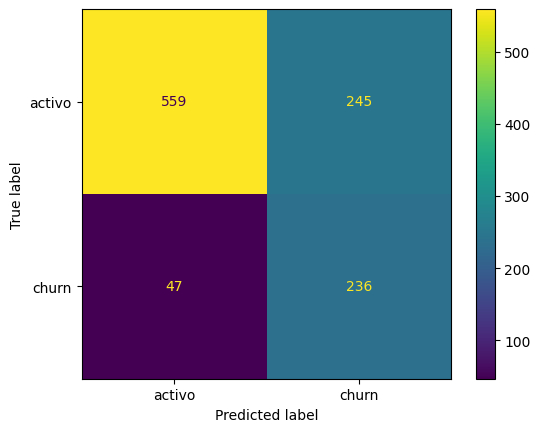



--- Reporte de Clasificación ---


              precision    recall  f1-score   support

           0       0.92      0.70      0.79       804
           1       0.49      0.83      0.62       283

    accuracy                           0.73      1087
   macro avg       0.71      0.76      0.71      1087
weighted avg       0.81      0.73      0.75      1087



In [19]:
try:
    # Entrenamos el pipeline con el conjunto de entrenmiento
    pipeline.fit(X_train, y_train)
    # Calculamos la prediccion del modelo para y_prevista: mediante la variable X_val
    y_prevista = pipeline.predict(X_val)

    print("--- Matriz de Confusión (Con pipeline para validacion ) ---")
    print('\n')
    # creamos visual de la matriz de confusión con y_val: validación y y_prevista: prevista por el modelo con X_val
    visual = ConfusionMatrixDisplay.from_predictions(y_val, y_prevista, display_labels=['activo','churn'])
    plt.show()
    print('\n')

    # Imprimimos el reporte del modelo con las diferentes métricas
    print("--- Reporte de Clasificación ---")
    print('\n')
    print(classification_report(y_val, y_prevista))

except Exception as e:
  print(f'Error al evaluar el modelo Árbol de Decisión: {e}')

### **Evaluación Final del Modelo: Generalización con Datos de Prueba**

Para concluir el proceso, sometimos el [Pipeline](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html) optimizado a una prueba de fuego utilizando el conjunto de datos de prueba (`X_test`, `y_test`), el cual permaneció totalmente aislado durante las fases de entrenamiento y validación. El objetivo es determinar la capacidad real de generalización del modelo y observar cómo se desempeñaría en un entorno de producción real para detectar el abandono de clientes (*Churn*).

**Análisis de la Matriz de Confusión y Métricas Finales:**
Al evaluar el modelo con estos datos inéditos, observamos una consistencia notable en los resultados:

* **Recall del 76%:** El modelo logra identificar correctamente a 76 de cada 100 clientes que realmente abandonan la empresa. En la matriz de confusión, esto se traduce en **216 aciertos** positivos frente a solo 68 omisiones (falsos negativos).
* **Precisión del 51%:** De cada 100 clientes que el modelo etiqueta como "Churn", 51 efectivamente se marcharon, mientras que 49 resultaron ser falsas alarmas.
* **F1-Score de 0.61:** Esta métrica confirma que hemos logrado un equilibrio robusto, superando con creces la capacidad predictiva de cualquier modelo previo.

**Consideraciones Estratégicas para el Negocio:**
La aceptación de este nivel de "falsas alarmas" depende estrictamente del modelo de costos de la empresa:

* **Prioridad en Retención:** Si el costo de perder un cliente es significativamente mayor al costo de ofrecer un bono o descuento, este modelo es ideal, ya que su alta sensibilidad (Recall) garantiza que muy pocos clientes en riesgo pasen desapercibidos.
* **Optimización de Recursos:** Si el negocio requiere una mayor exactitud en sus campañas para no desperdiciar incentivos en clientes que no pensaban irse, se podrían ajustar los umbrales de clasificación para balancear la precisión.

Sin embargo, dado que el objetivo primordial es mitigar el abandono, este rendimiento del **76% en Recall** sitúa a la empresa en una posición proactiva para ejecutar planes de acción efectivos y reducir la fuga de clientes.

--- Matriz de Confusión (Con pipeline para prueba ) ---




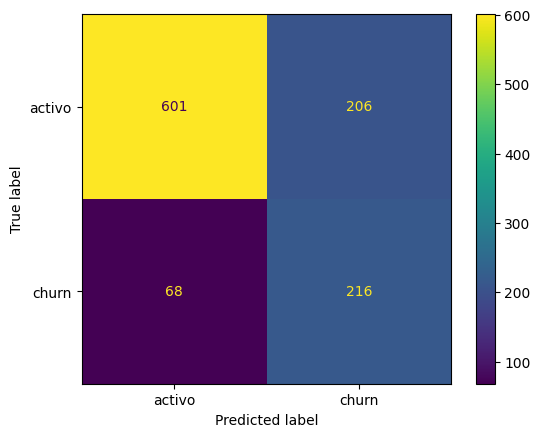



--- Reporte de Clasificación ---


              precision    recall  f1-score   support

           0       0.90      0.74      0.81       807
           1       0.51      0.76      0.61       284

    accuracy                           0.75      1091
   macro avg       0.71      0.75      0.71      1091
weighted avg       0.80      0.75      0.76      1091



In [20]:
try:

    # Entrenamos el pipeline con el conjunto de datos completo excepto los valores de prueba
    pipeline.fit(X_tratada, y_tratada)
    # Calculamos la prediccion del modelo para y_final: mediante la variable X_test
    y_final = pipeline.predict(X_test)


    print("--- Matriz de Confusión (Con pipeline para prueba ) ---")
    print('\n')
    # creamos visual de la matriz de confusión con y_test: prueba y y_final: prevista por el modelo con X_test
    visual = ConfusionMatrixDisplay.from_predictions(y_test, y_final, display_labels=['activo','churn'])
    plt.show()
    print('\n')

    # Imprimimos el reporte del modelo con las diferentes métricas
    print("--- Reporte de Clasificación ---")
    print('\n')
    print(classification_report(y_test, y_final))

except Exception as e:
  print(f'Error al evaluar el modelo Árbol de Decisión: {e}')

### **Optimización del Modelo: RandomForest y GridSearchCV**

Implementamos el uso de [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html), un modelo de ensamble significativamente más robusto que los árboles de decisión individuales utilizados anteriormente. Este clasificador funciona mediante la creación de múltiples árboles de decisión independientes; cada árbol se evalúa de forma individual y sus resultados se promedian para generar la predicción final. Este enfoque de "votación" reduce drásticamente la varianza y el riesgo de sobreajuste (*overfitting*).

Para potenciar este modelo, utilizamos [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), una herramienta de optimización que automatiza la búsqueda de la mejor combinación de hiperparámetros. Además de encontrar la configuración ideal, realiza una **validación cruzada (Cross-Validation)**, lo que garantiza que el rendimiento del modelo sea estable y no producto del azar o de una división específica de los datos.

#### **1. Configuración del estimador base**

Definimos el modelo base asignando la semilla `random_state=42` para garantizar que los experimentos sean reproducibles. Aplicamos también `class_weight='balanced'`, un parámetro crítico en nuestro caso, ya que ajusta automáticamente los pesos de las clases para dar mayor importancia a los clientes que abandonan (clase minoritaria) frente a los que permanecen.

```python
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

```

#### **2. Definición de la malla de hiperparámetros (Param Grid)**

Establecemos un diccionario con los parámetros que `GridSearchCV` evaluará. Por ejemplo, `'n_estimators'` define cuántos árboles de decisión compondrán nuestro bosque en cada iteración de prueba.

```python
param_grid = {
        'n_estimators': [100,200,300],
        'max_depth': [4,6,8,10,20, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 5, 10, 20],
        'bootstrap': [True,False]
    }

```

#### **3. Ejecución de la búsqueda exhaustiva**

Configuramos el objeto `GridSearchCV` integrando el modelo y la malla de parámetros. Aplicamos un `cv=5` (validación cruzada de 5 pliegues) y `n_jobs=-1` para procesar las combinaciones en paralelo, optimizando el tiempo de cómputo. Definimos el **Recall** como la métrica principal de evaluación, dada la naturaleza de nuestro problema de Churn.

```python
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='recall')

```

#### **4. Entrenamiento y ajuste**

Iniciamos el proceso de búsqueda para identificar y entrenar el modelo con la configuración que maximice el Recall.

```python
grid_search.fit(X_train, y_train)

```

#### **5. Análisis de Resultados**

Extraemos los resultados clave para comprender la arquitectura del modelo con mejor rendimiento:

* **`best_params_['max_depth']`**: Indica la profundidad óptima que alcanzó el modelo para generalizar correctamente.
* **`best_params_['min_samples_split']`**: Define el número mínimo de muestras necesarias para dividir un nodo interno.
* **`best_params_['min_samples_leaf']`**: Establece la cantidad mínima de datos que debe contener una hoja final.
* **`best_params_["bootstrap"]`**: Indica si se utilizó la técnica de muestreo con reemplazo para construir los árboles.
* **`best_score_`**: Representa el mejor Recall promedio obtenido durante la validación cruzada.
* **`score(X_val, y_val)`**: Refleja el rendimiento final obtenido al enfrentarse a los datos de validación, confirmando la capacidad del modelo ante datos no vistos.

```python
print(f"Mejor profundidad (max_depth): {grid_search.best_params_['max_depth']}")
print(f"Mejor min_samples_split: {grid_search.best_params_['min_samples_split']}")
print(f"Mejor min_samples_leaf: {grid_search.best_params_['min_samples_leaf']}")
print(f"Mejor bootstrap: {grid_search.best_params_['bootstrap']}")
print(f"Mejor Recall en entrenamiento (CV): {grid_search.best_score_:.4f}")
print(f"Recall final en Validación: {grid_search.score(X_val, y_val):.4f}")

```





In [21]:
try:

    # Importamos funciones
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import GridSearchCV

    # Definimos el modelo y los parametros
    rf = RandomForestClassifier(random_state=42, class_weight='balanced')
    param_grid = {
        'n_estimators': [100,200,300],
        'max_depth': [4,6,8,10,20, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 5, 10, 20],
        'bootstrap': [True,False]
    }

    # Configuramos la búsqueda (CV=5 para validación cruzada de 5 pliegues) en conjunto de los demás parámetros
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='recall')
    # Entrenamos el modelo con la mejor configuración
    grid_search.fit(X_train, y_train)

    # 5. Resultados
    print(f"Mejor profundidad (max_depth): {grid_search.best_params_['max_depth']}")
    print(f'Mejor min_samples_split: {grid_search.best_params_['min_samples_split']}')
    print(f'Mejor min_samples_leaf: {grid_search.best_params_['min_samples_leaf']}')
    print(f'Mejor bootstrap: {grid_search.best_params_["bootstrap"]}')
    print(f"Mejor precisión en entrenamiento (CV): {grid_search.best_score_:.4f}")
    print(f"Precisión final en Validación: {grid_search.score(X_val, y_val):.4f}")

except Exception as e:
  print(f'Error al evaluar el modelo Árbol de Decisión: {e}')

Mejor profundidad (max_depth): 4
Mejor min_samples_split: 2
Mejor min_samples_leaf: 10
Mejor bootstrap: True
Mejor precisión en entrenamiento (CV): 0.7847
Precisión final en Validación: 0.8198


### **Instanciación y Evaluación del Modelo Optimizado (Random Forest)**

Tras completar la búsqueda de hiperparámetros mediante `GridSearchCV`, definimos el objeto `forest_final` para almacenar el modelo que demostró el mejor desempeño y configuración técnica. Procedimos a entrenar este modelo utilizando el conjunto de entrenamiento (`X_train`, `y_train`) y, posteriormente, evaluamos su capacidad predictiva con los datos de validación (`X_val`) para confirmar la estabilidad de las métricas obtenidas.

**Análisis del Rendimiento Final en Validación:**
Al probar el modelo optimizado con los datos de validación, obtuvimos resultados significativamente superiores a nuestras iteraciones previas:

* **Recall del 82%:** El modelo identifica correctamente a la gran mayoría de los clientes con intención de abandono.
* **Precisión del 52%:** Logramos un equilibrio donde un poco más de la mitad de nuestras alertas de *Churn* son aciertos reales, optimizando el uso de recursos para campañas de retención.
* **F1-Score de 0.64:** Este valor consolida al **Random Forest** como el modelo más robusto del proyecto, ofreciendo la mejor relación entre sensibilidad y precisión para la toma de decisiones estratégicas.

--- Matriz de Confusión (Con forest optimizado para validación ) ---




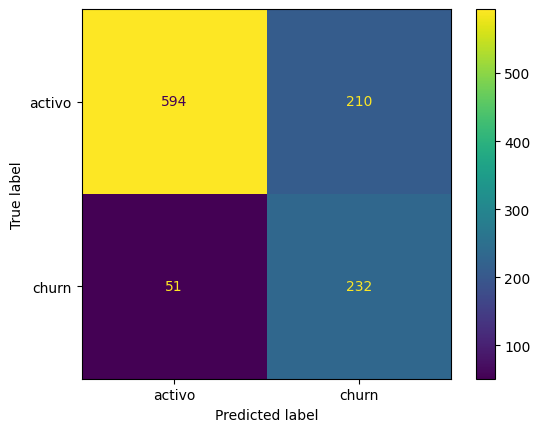

--- Reporte de clasificación del Rendimiento en validación ---



               precision    recall  f1-score   support

           0       0.92      0.74      0.82       804
           1       0.52      0.82      0.64       283

    accuracy                           0.76      1087
   macro avg       0.72      0.78      0.73      1087
weighted avg       0.82      0.76      0.77      1087



In [22]:
try:
    # Creamos forest_final que almacena el mejor estimador con la configuracion para el random forest
    forest_final = grid_search.best_estimator_
    #Entrenamos el modelo forest final con el conjunto de datos de entrenamiento
    forest_final.fit(X_train, y_train)
    # Creacmos y_pred_forest con los valores previstos por X_val
    y_pred_forest = forest_final.predict(X_val)

    print("--- Matriz de Confusión (Con forest optimizado para validación ) ---")
    print('\n')

    # Visualizamos los resultados con una matriz de confusión
    visual_nueva = ConfusionMatrixDisplay.from_predictions(y_val, y_pred_forest, display_labels=['activo','churn'])
    # mostramos el resultado
    plt.show()

    print(f'--- Reporte de clasificación del Rendimiento en validación ---')
    print('\n')
    print(f'\n {classification_report(y_val,y_pred_forest)}')

except Exception as e:
  print(f'Error al evaluar el modelo Random Forest: {e}')

### **Evaluación Final del Modelo Optimizado en el Conjunto de Prueba (Test)**

Procedimos a realizar la evaluación definitiva de nuestro modelo. Para ello, utilizamos el objeto `forest_final`, que contiene el mejor estimador identificado durante la fase de optimización de hiperparámetros. Ejecutamos el método `predict` sobre el conjunto de características de prueba (`X_test`), generando las predicciones finales (`y_final_forest`). Posteriormente, utilizamos `ConfusionMatrixDisplay` y `classification_report` para auditar el rendimiento del modelo comparando estas predicciones contra las etiquetas reales (`y_test`).

**Análisis de Resultados de Negocio (Test Set):**
Los resultados obtenidos en este conjunto de datos nunca antes visto por el modelo confirman su sólida capacidad de generalización:

* **Recall del 79% (Clase Churn):** El modelo logra identificar correctamente a 79 de cada 100 clientes que efectivamente abandonan la empresa. En términos absolutos, esto corresponde a **224 aciertos positivos** frente a solo 60 omisiones (falsos negativos). Esta alta sensibilidad cumple con nuestro objetivo principal de minimizar la fuga de clientes no detectados.
* **Precisión del 51% (Clase Churn):** De todas las alertas de abandono generadas por el modelo, el 51% son aciertos reales, mientras que el 49% restante (219 casos) corresponden a falsos positivos. Este equilibrio es aceptable dado el enfoque proactivo de retención.
* **F1-Score del 0.62:** Esta métrica, que combina precisión y recall, ratifica la robustez del modelo final frente a datos nuevos, superando significativamente el rendimiento de las iteraciones anteriores.

En conclusión, la evaluación final en el set de prueba demuestra que el modelo está listo para producción, ofreciendo una herramienta fiable y estable para identificar y retener a los clientes en riesgo de Churn.

--- Matriz de Confusión (Con forest optimizado para prueba ) ---




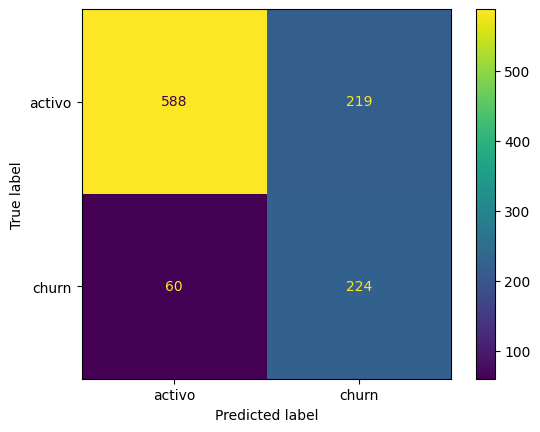



--- Reporte de clasificación del Rendimiento en prueba ---



               precision    recall  f1-score   support

           0       0.91      0.73      0.81       807
           1       0.51      0.79      0.62       284

    accuracy                           0.74      1091
   macro avg       0.71      0.76      0.71      1091
weighted avg       0.80      0.74      0.76      1091



In [23]:
try:
    # Entrenamos el modelo forest final con todo el conjunto de datos excepto los valores de prueba,
    # para evaluar la estabilidad y el rendimiento del modeló
    forest_final.fit(X_tratada, y_tratada)
    # Creacmos y_final_forest con los valores previstos por X_test
    y_final_forest = forest_final.predict(X_test)

    print("--- Matriz de Confusión (Con forest optimizado para prueba ) ---")
    print('\n')

    # Visualizamos los resultados con una matriz de confusión
    visual_nueva = ConfusionMatrixDisplay.from_predictions(y_test,y_final_forest, display_labels=['activo','churn'])
    # mostramos el resultado
    plt.show()
    print('\n')

    print(f'--- Reporte de clasificación del Rendimiento en prueba ---')
    print('\n')
    print(f'\n {classification_report(y_test,y_final_forest)}')

except Exception as e:
  print(f'Error al evaluar el modelo Random Forest: {e}')

### **Análisis de Importancia de Variables (Feature Importance)**

Para comprender los factores que impulsan el abandono de clientes, extrajimos y visualizamos las variables más influyentes del modelo final. Utilizamos el atributo `.feature_importances_` del objeto `forest_final`, que calcula automáticamente la importancia relativa de cada característica basándose en cuánto reduce la impureza de los nodos en los árboles de decisión del bosque aleatorio. Almacenamos estos valores junto con los nombres de las columnas en un DataFrame y los ordenamos de manera descendente para identificar los predictores clave.

**Análisis del Gráfico: "Top 10 Variables que influyen en el Churn (Abandono)"**
El gráfico de barras horizontal revela insights críticos para el negocio:

* **Factores Clave:** La variable más determinante con diferencia es **`num__tenure`** (antigüedad del cliente), seguida muy de cerca por **`cat__Contract_Two year`** (contrato a dos años) y **`cat__InternetService_Fiber optic`** (servicio de fibra óptica). Esto sugiere que la fidelidad a largo plazo y el tipo de servicio contratado son los principales impulsores del Churn.
* **Impacto Financiero:** Las variables relacionadas con los costos (**`num__ChargesTotal`**, **`num__ChargesMonthly`**, **`num__ChargesDaily_Total`**) también aparecen prominentemente en el Top 10.

Este análisis proporciona una hoja de ruta clara para que la empresa diseñe estrategias de retención, enfocándose en incentivar contratos a largo plazo, revisar la propuesta de valor de la fibra óptica y gestionar proactivamente a los clientes con alta antigüedad o cargos elevados.

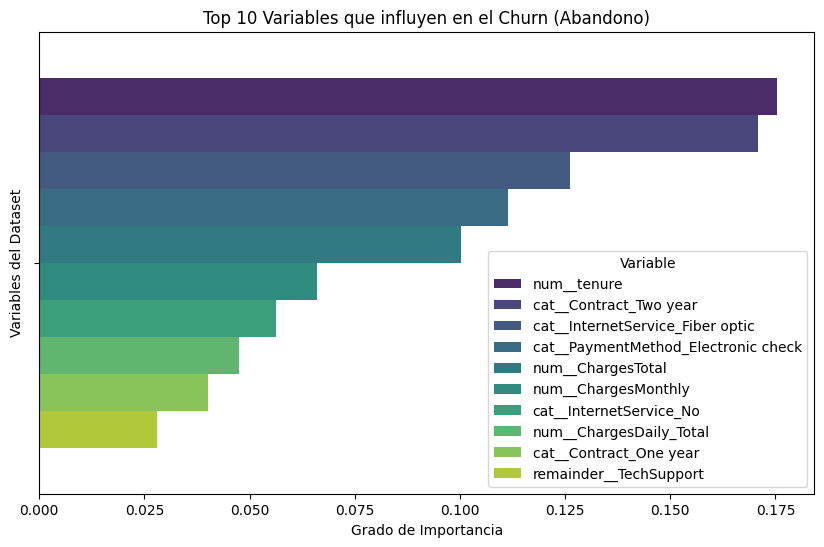

In [24]:
try:

    # Extraer las variables mas importantes del modelo final
    importancias = forest_final.feature_importances_
    # Variable que almacena los nombres de esas columnas
    nombres_columnas = X_tratada.columns

    # Creamos un DataFrame para facilitar la visualización
    feature_importance_df = pd.DataFrame({
        'Variable': nombres_columnas,
        'Importancia': importancias
    }).sort_values(by='Importancia', ascending=False)

    # Graficar las 10 variables más importantes
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df.head(10), x='Importancia', hue='Variable',  palette='viridis')
    plt.title('Top 10 Variables que influyen en el Churn (Abandono)')
    plt.xlabel('Grado de Importancia')
    plt.ylabel('Variables del Dataset')

except Exception as e:
  print(f'Error al evaluar el modelo Árbol de Decisión: {e}')
else:
  # mostramos el gráfico
  plt.show()

### **Exportación del Modelo y Dependencias**

Con el objetivo de permitir la reutilización del modelo en otros entornos o aplicaciones, procedemos a exportar el modelo final entrenado (`forest_final`) junto con el proceso de preprocesamiento de datos. Esto permite que el modelo pueda aplicarse directamente a nuevos datos sin necesidad de repetir el proceso de entrenamiento.

Para ello se utiliza la librería `joblib`, ampliamente utilizada para serializar modelos de Machine Learning en Python.

In [28]:
try:

    # Importamos librerías necesarias
    import joblib
    from sklearn.pipeline import Pipeline

    # Creamos un pipeline que incluye el tratamiento de datos y el modelo final
    pipeline_final = Pipeline([
        ('preprocesamiento', transformer),
        ('modelo', forest_final)
    ])

    # Exportamos el modelo entrenado
    joblib.dump(pipeline_final, 'modelo_churn_random_forest_pipeline.pkl')

    print("Modelo exportado correctamente como: modelo_churn_random_forest_pipeline.pkl")

except Exception as e:
    print(f"Error al exportar el modelo: {e}")

Modelo exportado correctamente como: modelo_churn_random_forest_pipeline.pkl


# 📊 Informe Final – Predicción de Cancelación de Clientes (Churn)

## Proyecto de Ciencia de Datos – Telecom X

---

# 1. Introducción

La cancelación de clientes, conocida en analítica de negocios como **Churn**, representa uno de los mayores desafíos para las empresas de telecomunicaciones. Cada cliente que abandona el servicio implica **pérdida de ingresos, costos de adquisición de nuevos clientes y reducción del valor de vida del cliente (Customer Lifetime Value).**

Ante este problema, el presente proyecto tiene como objetivo aplicar **técnicas de Ciencia de Datos y Machine Learning** para:

* Identificar los **factores que influyen en la cancelación de clientes**
* Construir modelos predictivos capaces de **anticipar qué clientes tienen mayor probabilidad de abandonar el servicio**
* Proponer **estrategias de retención basadas en datos**

Para lograrlo, se desarrolló un flujo completo de análisis que incluyó:

* limpieza y transformación de datos
* análisis exploratorio
* construcción de modelos de clasificación
* validación estadística
* optimización de hiperparámetros
* interpretación de resultados

Los modelos principales utilizados fueron:

* **Dummy Classifier (Baseline)**
* **Árbol de Decisión**
* **Random Forest**

---

# 2. Preparación y tratamiento de datos

El proceso comenzó con la carga del dataset previamente limpiado y transformado.

### Ejemplo del código utilizado

```python
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

datos = '/content/Analisis_Telecom_X_Limpio_y_Transformado'
df_telecomx = pd.read_csv(datos)
```

Posteriormente se realizó una **copia del dataset** y se eliminaron variables que no aportan valor predictivo, como el identificador del cliente.

```python
df_telecomx_nuevo = df_telecomx.copy()
df_telecomx_nuevo = df_telecomx_nuevo.drop(columns='customerID')
```

Este paso es importante porque:

* `customerID` es solo un identificador
* no aporta información útil para predecir churn
* puede generar **ruido en los modelos**

---

# 3. Ingeniería de características (Feature Engineering)

Se creó una nueva variable llamada **Phone_Category** para representar de forma más clara la configuración del servicio telefónico del cliente.

```python
conditions = [
(df_telecomx_nuevo['PhoneService'] == 1) & (df_telecomx_nuevo['MultipleLines'] == 1),
(df_telecomx_nuevo['PhoneService'] == 0) & (df_telecomx_nuevo['MultipleLines'] == 0)
]

categorias = ['Multiple Lines','No Phone Service']
```

La ingeniería de características permite:

* mejorar la interpretabilidad
* facilitar el aprendizaje del modelo
* capturar relaciones ocultas entre variables

---

# 4. Separación de variables

Se separaron las variables explicativas y la variable objetivo.

```python
y = df_telecomx_nuevo['Churn']
X = df_telecomx_nuevo.drop(columns='Churn')
```

Donde:

* **y → variable objetivo (cancelación)**
* **X → variables predictoras**

---

# 5. Transformación de variables

Debido a la presencia de variables categóricas y numéricas, se utilizó **ColumnTransformer**.

```python
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
```

Esto permitió:

* aplicar **One Hot Encoding** a variables categóricas
* aplicar **StandardScaler** a variables numéricas

De esta manera los modelos pueden procesar los datos correctamente.

---

# 6. Análisis de correlación

Se analizó la relación entre las variables y la cancelación del cliente.

```python
corr_final = X_final.corrwith(y).sort_values(ascending=False)

plt.figure(figsize=(8, 12))
sns.heatmap(corr_final.to_frame(), annot=True, cmap='RdYlGn')
```

📊 **Interpretación del gráfico**

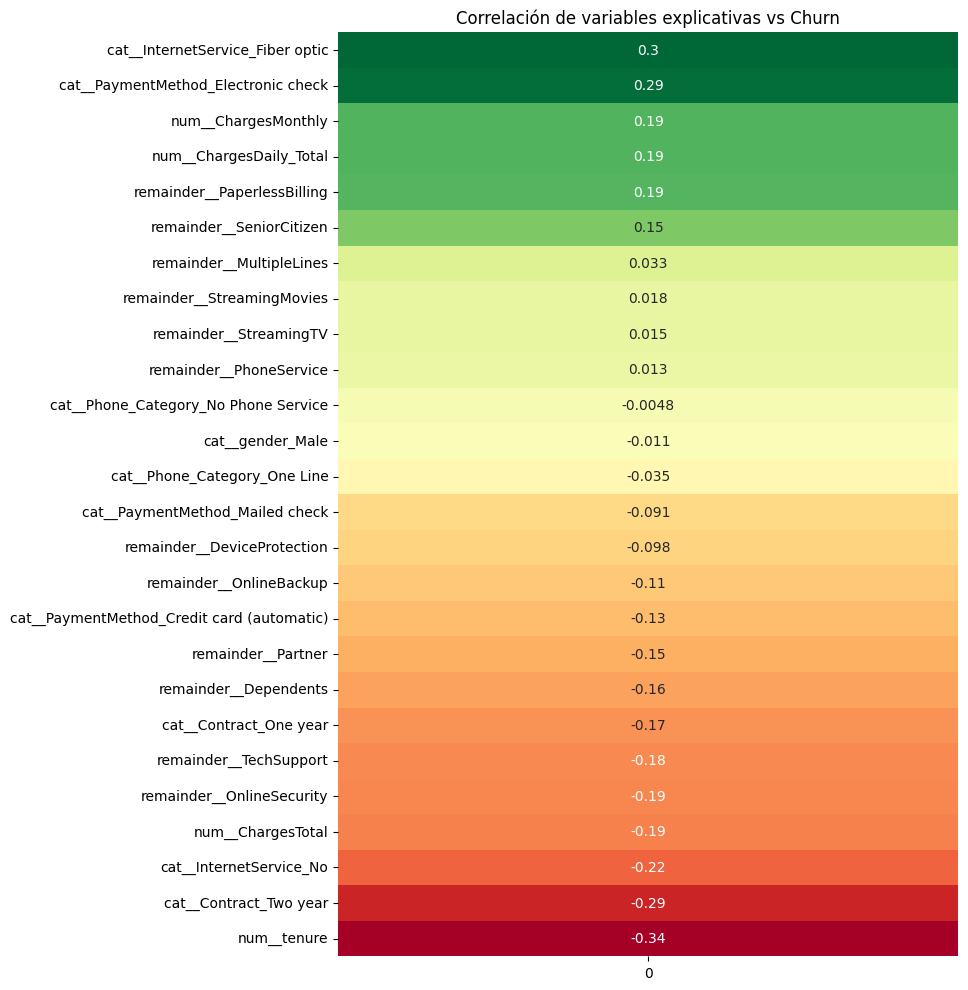

Este mapa de calor permite identificar qué variables tienen mayor relación con el churn. Estas son las que estan más cerca de 1 y las variables más cerca de -1 representan baja correlación con la variable objetivo churn.

Las variables con mayor impacto incluyen:

* tipo de contrato
* cargos mensuales
* tipo de servicio de internet
* duración del cliente en la empresa

Este análisis inicial proporciona una **intuición sobre qué factores influyen en la cancelación**.

---

# 7. División del dataset

Para evaluar correctamente los modelos, el dataset fue dividido en:

* **70% entrenamiento**
* **15% prueba**
* **15% validación**

```python
X_tratada, X_test, y_tratada, y_test = train_test_split(
X_final, y, test_size=0.15, stratify=y, random_state=42)
```
y

```python
X_train, X_val, y_train, y_val = train_test_split(
X_tratada, y_tratada, test_size=0.176, stratify=y_tratada, random_state=42)
```


Esto garantiza que el modelo sea entrenado y evaluado para luego ser probado con **datos nunca vistos durante el entrenamiento**.

---

# 8. Modelo Baseline

El primer modelo utilizado fue **DummyClassifier**, que sirve como referencia mínima.

```python
from sklearn.dummy import DummyClassifier

base_model = DummyClassifier(random_state=42)
base_model.fit(X_train, y_train)
```

Este modelo simplemente predice la clase más frecuente.

📊 Su propósito es responder la pregunta:

> ¿Nuestro modelo realmente aprende o solo adivina?

---

# 9. Modelo Árbol de Decisión

Posteriormente se entrenó un **Decision Tree Classifier**.

```python
from sklearn.tree import DecisionTreeClassifier

modelo_arbol = DecisionTreeClassifier(max_depth=4,random_state=42)
modelo_arbol.fit(X_train, y_train)
```

Se probaron diferentes profundidades:

```
3
6
9
12
```

Esto permitió controlar el **overfitting**.

---

# 10. Manejo del desbalance de clases

Los problemas de churn suelen presentar **clases desbalanceadas**.

Por ello se aplicó **SMOTE (Synthetic Minority Oversampling Technique)**.

```python
from imblearn.over_sampling import SMOTE
```

SMOTE genera **nuevos ejemplos sintéticos de la clase minoritaria**, mejorando la capacidad del modelo para detectar cancelaciones.

---

# 11. Validación cruzada

Se utilizó **Stratified K-Fold** para validar el modelo.

```python
from sklearn.model_selection import StratifiedKFold
```

Esto permite:

* evaluar el modelo en múltiples particiones
* reducir el riesgo de resultados sesgados

La métrica principal utilizada fue:

🎯 **Recall**

Porque en churn es más importante:

> Detectar clientes que podrían irse.

---

# 12. Modelo Random Forest (Modelo Final)

El modelo final fue **Random Forest**, que combina múltiples árboles de decisión.

```python
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
```

Se optimizaron hiperparámetros mediante **GridSearchCV**.

```python
param_grid = {
'n_estimators': [...],
'max_depth': [...],
'min_samples_split': [...]
}
```

Este proceso permite encontrar la **mejor configuración del modelo**.

---

# 13. ¿Por qué Random Forest fue el mejor modelo?

El Random Forest superó a los otros modelos por varias razones.

### 1️⃣ Reduce el overfitting

Un solo árbol de decisión puede memorizar los datos.

Random Forest:

* construye **muchos árboles**
* cada uno aprende de una muestra diferente
* las predicciones se combinan

Esto reduce la varianza del modelo.

---

### 2️⃣ Mayor capacidad de generalización

El modelo logra capturar **relaciones complejas entre variables** que un solo árbol no puede detectar.

---

### 3️⃣ Mejor rendimiento en métricas

El modelo mostró:

* mayor **recall**
* mejor **capacidad de detectar churn**
* mayor estabilidad en validación cruzada

---

# 14. Importancia de variables

El modelo Random Forest permite analizar **feature importance**.

```python
importancias = forest_final.feature_importances_
```

Esto permitió identificar las variables más influyentes.

Entre las más relevantes se encuentran:

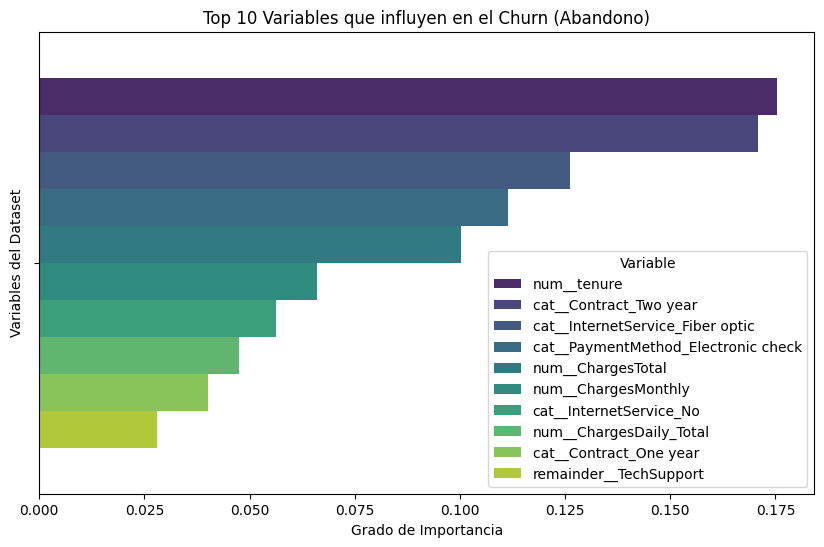

📊 **Principales factores de cancelación**

* Tipo de contrato
* Cargos mensuales
* Tiempo del cliente en la empresa (tenure)
* Costo total del servicio
* Método de pago
* Tipo de servicio de internet

---

# 15. Interpretación de resultados

Los resultados indican que la cancelación está fuertemente relacionada con:

### Clientes con bajo compromiso

Clientes con contratos **mensuales** tienden a cancelar más.

---

### Costos del servicio

Cargos mensuales elevados aumentan la probabilidad de churn.

---

### Antigüedad del cliente

Clientes nuevos presentan mayor probabilidad de abandono.

---

# 16. Estrategias de retención basadas en datos

A partir del análisis realizado se proponen las siguientes estrategias.

### 1️⃣ Programas de fidelización para clientes nuevos

Reducir churn en los primeros meses mediante:

* descuentos iniciales
* beneficios exclusivos
* soporte personalizado

---

### 2️⃣ Incentivos para contratos largos

Ofrecer beneficios para clientes que elijan contratos anuales.

---

### 3️⃣ Optimización de planes de precios

Diseñar paquetes con mayor valor percibido.

---

### 4️⃣ Sistemas de alerta temprana

Utilizar el modelo desarrollado para detectar clientes con alto riesgo de cancelación y aplicar acciones preventivas.

---

# ✅Conclusión

> Este proyecto demuestra cómo los datos pueden transformar la forma en que una empresa entiende a sus clientes.
>
> Lo que comenzó como un conjunto de miles de registros de clientes se convirtió, a través del análisis y el machine learning, en una herramienta capaz de anticipar el comportamiento de los usuarios.
>
> Mediante técnicas como árboles de decisión, validación cruzada y modelos de ensamblado como Random Forest, fue posible identificar patrones claros detrás de la cancelación de clientes.
>
> Descubrimos que factores como el tipo de contrato, el costo del servicio y la antigüedad del cliente juegan un papel determinante en la probabilidad de churn.
>
> Pero más allá del modelo, el verdadero valor de este análisis está en su aplicación práctica: permitir a una empresa identificar clientes en riesgo y actuar antes de que abandonen el servicio.

> El proyecto no solo se basó en construir un modelo predictivo, sino que demostró el verdadero propósito de la Ciencia de Datos: transformar información en decisiones estratégicas.
>
> A través del análisis realizado, se logró pasar de datos históricos a conocimiento accionable, identificando los factores que influyen en la cancelación de clientes y proponiendo estrategias concretas de retención.
>
> El modelo Random Forest demostró ser la mejor solución para este problema, ofreciendo mayor capacidad de generalización y mejor rendimiento predictivo.
>
> Este tipo de herramientas permite a las organizaciones anticiparse al comportamiento de sus clientes, optimizar sus estrategias comerciales y mejorar la fidelización.
>
> En un mundo cada vez más impulsado por datos, la capacidad de convertir información en conocimiento es lo que diferencia a las empresas que reaccionan de aquellas que se anticipan.